In [4]:
from d_CSL import GcStar

In [1]:
# import sys
# sys.path.append(r"../")
# sys.path.append(r'C:\Users\sadiq\Desktop\U_Vienna\codes\icm-zebrafish')
import numpy as np
import matplotlib.pyplot as plt
# from d_CSL import *
from tqdm.notebook import tqdm
from reloading import reloading

In [6]:
%reload_ext autoreload
%autoreload 2
from d_CSL import *

In [7]:
gcstar = GcStar(n_perm=10, n_pasts=5, n_lags=1,temporal=True)

In [8]:
np.random.seed(3465)
n_neur=20
A = np.random.choice([0,0.5,0.85], p=[0.9,0.03,0.07], size=(n_neur,n_neur)) ### A is not the adjacency matrix in the typical sense
A = 0.5*(A)
A[0:10,0:10] =np.zeros((10,10))
for n, i in enumerate(A):
    A[n][n]=1
for n, i in enumerate(A):
    A[n]=A[n]/np.sum(A[n])
A.shape

(20, 20)

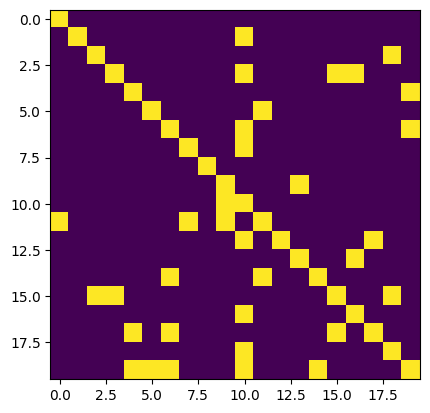

In [9]:
plt.imshow(A!=0)
# plt.grid()

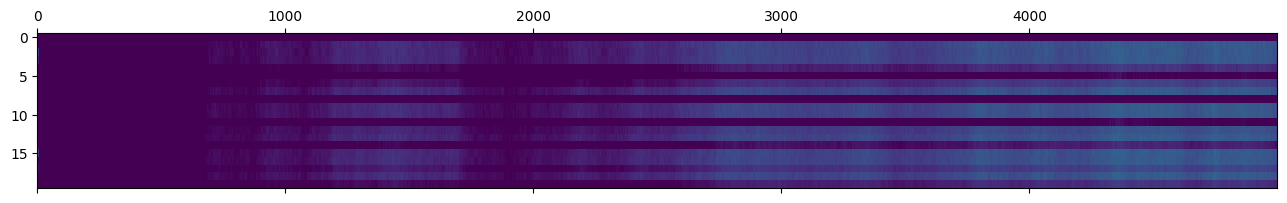

In [10]:
X = np.zeros([A.shape[0],5000]).T
X[0] = np.random.randn(A.shape[0])
for i, row in enumerate(X[:-1]):
    X[i+1] = A @ X[i] + 0.05*np.random.normal(0,0.25,A.shape[0])
X=X.T
plt.matshow(X, aspect='auto',vmin=0)

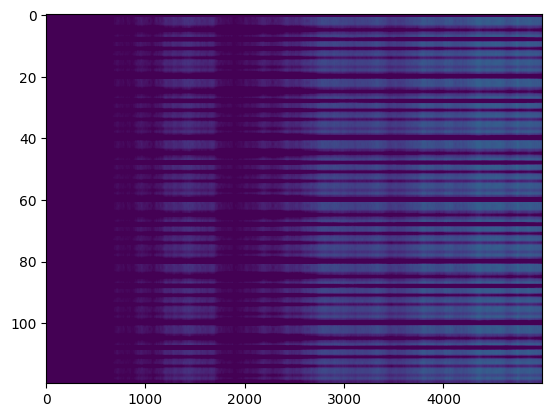

In [11]:
plt.imshow(gcstar.shift_data(arr=X), aspect='auto', vmin=0)

In [12]:
print(gcstar.get_number_of_neurons())

20


In [13]:
%%time
corr, pVal_corr = gcstar.correlation_func() 

CPU times: total: 4.94 s
Wall time: 6.02 s


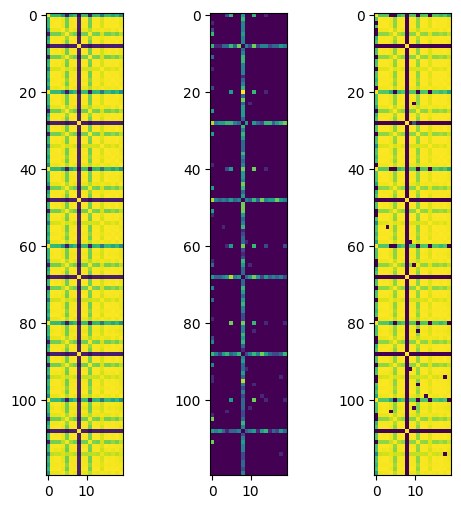

In [14]:
fig,ax = plt.subplots(1,3,figsize=(6,6))
ax[0].imshow(corr)
ax[1].imshow(pVal_corr)
ax[2].imshow(np.multiply(corr,pVal_corr<=.01))

None


In [16]:
%%time
inv_corr, pVal_inv_corr = gcstar.inv_correlation_func()

CPU times: total: 3min 53s
Wall time: 3min


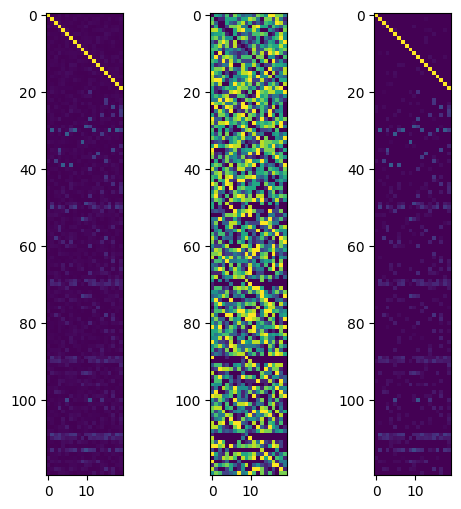

In [17]:
fig,ax = plt.subplots(1,3,figsize=(6,6))
ax[0].imshow(inv_corr)
ax[1].imshow(pVal_inv_corr)
ax[2].imshow(np.multiply(inv_corr, pVal_inv_corr<=.001))

In [19]:
gcstar.fit(X)

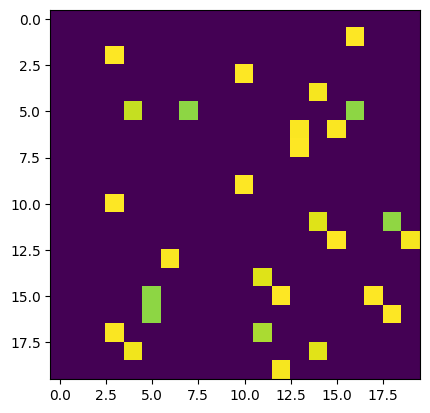

In [21]:
plt.imshow(gcstar.get_connectivity_matrix(0.01, 0.001))

In [37]:
p = np.transpose(np.where(gcstar.conn_mat != 0))
print(p[0])

[ 1 16]


In [25]:
print(gcstar.compute_confusion_matrix(A.T))

[[  4  49]
 [ 24 323]]


In [26]:
gcstar.compute_metrics()

array([0.8175    , 0.14285714, 0.0754717 , 0.06916427])

In [27]:
from d_CSL import Visualize_on_topography

In [28]:
visualize = Visualize_on_topography(10,5,3)

In [ ]:
visualize.repopulate(np.)

In [ ]:
### test data

In [25]:
x_idx = [0 + a * 10 for a in range(4)]
np.array(x_idx).astype(int)

array([ 0, 10, 20, 30])

In [18]:
def prep_data(X, nn):
    if nn == None or nn == 0:
        X_ = X
        return X_
    else:
        X_ = X[:,(nn):]
        for i in range(nn):
            idx1, idx2 = nn-1-i,-i-1
            X_ = np.r_[X_, X[:,idx1:idx2]]
        return X_
    
def get_cond_set(X, n_pasts, i, j) -> np.ndarray:
    n_neur = X.shape[0]
    k, i_ = i // n_neur, i % n_neur
    shifted = prep_data(X, n_pasts)
    
    x_idx = [i_ + a * n_neur for a in range(k)]
        

    # Exclude variables 'i' and 'k * n' from the shifted_data
    z = np.delete(shifted, np.r_[np.array(x_idx), [i, j]], axis=0)

    return z

In [19]:
new = np.arange(80).reshape(4,20)
print(new)

[[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59]
 [60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79]]


In [20]:
prep_data(new, 5)

array([[ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
       [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
       [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
       [65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79],
       [ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
       [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38],
       [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58],
       [64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78],
       [ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17],
       [23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37],
       [43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57],
       [63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77],
       [ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
       [22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36],
       [42, 43, 44, 45, 46, 47, 48

In [21]:
get_cond_set(new, 5, 12, 3)

array([[25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
       [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
       [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38],
       [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58],
       [64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78],
       [23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37],
       [43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57],
       [63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77],
       [22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36],
       [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56],
       [62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
       [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35],
       [41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55],
       [61, 62, 63, 64, 65, 66, 67

In [5]:
[12+10*a for a in range(4)]

[12, 22, 32, 42]

array([[ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
       [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
       [ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
       [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38],
       [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58],
       [ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17],
       [23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37],
       [43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57],
       [ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
       [22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36],
       [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
       [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35],
       [41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55],
       [ 0,  1,  2,  3,  4,  5,  6

In [60]:
conditioning_set_(new,5,12,2)

array([[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
       [41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55],
       [ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
       [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54],
       [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
       [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38],
       [23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37],
       [22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36],
       [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35],
       [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]])

In [49]:
new

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19],
       [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39],
       [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
        56, 57, 58, 59]])